# *Data_Science_GP*
# *Analysis of Factors Affecting Employee Attrition*

# Stage 1: Data Cleaning & Preprocessing

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np

In [2]:
# Upload files
from google.colab import files
uploaded = files.upload()

Saving HR_Attrition Data.csv to HR_Attrition Data.csv


In [3]:
from google.colab import files
uploaded = files.upload()

Saving HR_New_data.csv to HR_New_data.csv


In [4]:
# Read the datasets
df1 = pd.read_csv('HR_Attrition Data.csv')
df2 = pd.read_csv('HR_New_data.csv')

In [5]:
# Check basic information of both datasets
print("=== HR_Attrition Data Info ===")
print(f"Shape: {df1.shape}")
print(df1.columns.tolist())

print("\n=== HR_New_data Info ===")
print(f"Shape: {df2.shape}")
print(df2.columns.tolist())

=== HR_Attrition Data Info ===
Shape: (1470, 26)
['Employee No.', 'Gender', 'Education', 'Education Field', 'Job Role', 'Department', 'Age group', 'Work Location', 'Attrition', 'Attrition Date', 'Attrition Label', 'Dynamic Date', 'Age', 'Attrition.1', 'Avg. Satisfaction Score', 'Employee Count', 'Environment Satisfaction', 'Attrition Count', 'Job Involvement', 'Job Satisfaction', 'Monthly Income', 'Percent Salary Hike', 'Performance Rating', 'Placeholder', 'Relationship Satisfaction', 'Work Life Balance']

=== HR_New_data Info ===
Shape: (1470, 6)
['emp_id', 'last_evaluation', 'number_project', 'average_montly_hours', 'Work_accident', 'promotion_last_5years']


In [6]:
# Unified ID Name
df1 = df1.rename(columns={'Employee No.':'emp_id'})

# Merge the datasets
df = pd.merge(df1, df2, on='emp_id', how='left')

print("Data Info after Merging",df.shape)

df.head()

Data Info after Merging (1470, 31)


,emp_id,Gender,Education,Education Field,Job Role,Department,Age group,Work Location,Attrition,Attrition Date,...,Percent Salary Hike,Performance Rating,Placeholder,Relationship Satisfaction,Work Life Balance,last_evaluation,number_project,average_montly_hours,Work_accident,promotion_last_5years
0,E_1,Female,Associates Degree,Life Sciences,Sales Executive,Sales,35-44,Banglore,Yes,4/30/2022,...,11,3,0,1,1,0.53,2,157,0,0
1,E_2,Male,High School,Life Sciences,Research Scientist,R & D,45-55,Hydrabad,No,NaN,...,23,4,0,4,3,0.74,4,215,0,0
2,E_4,Male,Associates Degree,Other,Laboratory Technician,R & D,35-44,Noida,Yes,5/3/2022,...,15,3,0,2,3,0.86,5,262,0,0
3,E_5,Female,Master's Degree,Life Sciences,Research Scientist,R & D,25-34,Pune,No,NaN,...,11,3,0,3,3,0.67,2,202,0,0
4,E_7,Male,High School,Medical,Laboratory Technician,R & D,25-34,Mumbai,No,NaN,...,12,3,0,4,3,0.69,5,193,0,0


In [7]:
# Find missing value
missing_ratio = df.isnull().mean().sort_values(ascending=False)

missing_table = pd.DataFrame({
    'missing_count':df.isnull().sum(),
    'missing_ratio':missing_ratio
})

missing_table

,missing_count,missing_ratio
Age,0,0.000000
Age group,0,0.000000
Attrition,0,0.000000
Attrition Count,1233,0.838776
Attrition Date,1233,0.838776
Attrition Label,0,0.000000
Attrition.1,0,0.000000
Avg. Satisfaction Score,0,0.000000
Department,0,0.000000
Dynamic Date,1233,0.838776


*The variables Attrition Date, Attrition Count, and Dynamic Date have missing ratios exceeding 80%.
This is mainly because these variables only exist for employees who have already left the company.
For active employees, these values are naturally missing.

Since our goal is to predict employee attrition in advance, these variables would introduce data leakage and therefore were removed from the dataset.

In [8]:
# Drop three columns
df = df.drop(columns=[
    'Attrition Date',
    'Attrition Count',
    'Dynamic Date'
], errors='ignore')

In [9]:
# Check missing value again
df.isnull().sum()

,0
emp_id,0
Gender,0
Education,0
Education Field,0
Job Role,0
Department,0
Age group,0
Work Location,0
Attrition,0
Attrition Label,0


# Stage 2: Exploratory Data Analysis

In [10]:
# Import libraries
import matplotlib.pyplot as plt
import seaborn as sns

1. The relationship between income and attrition

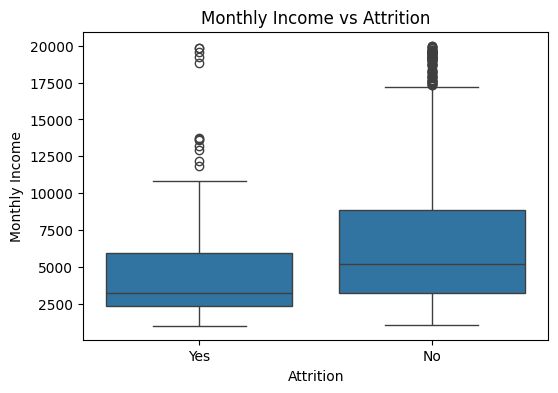

,Monthly Income
Attrition,
No,6832.739659
Yes,4787.092827


In [11]:
# Income and Attrition
plt.figure(figsize=(6,4))
sns.boxplot(x="Attrition",y="Monthly Income",data=df)
plt.title("Monthly Income vs Attrition")
plt.show()

df.groupby('Attrition')['Monthly Income'].mean()

2. Relationship between Number of Projects and Employee Attrition Rate

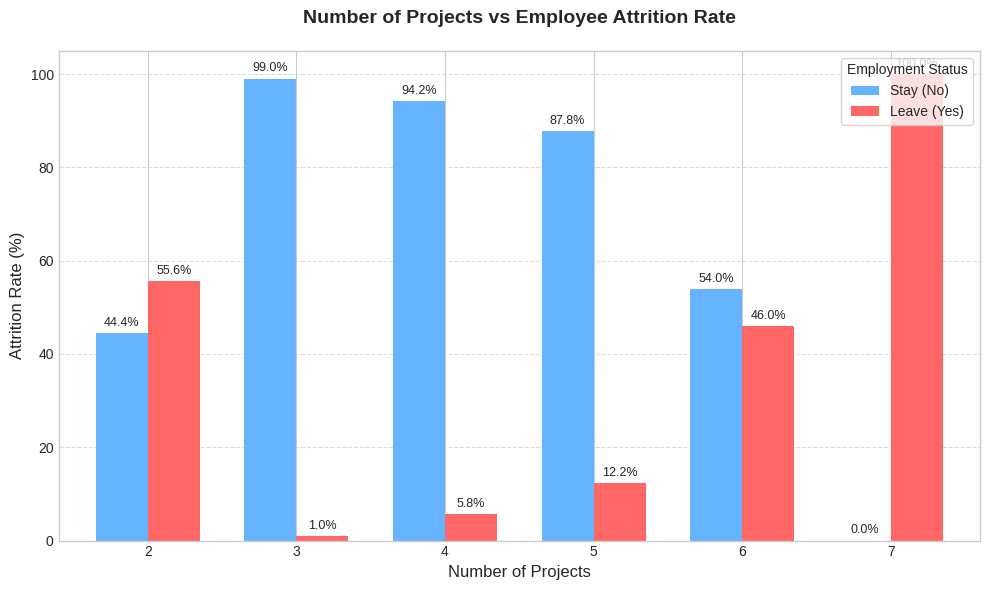

In [12]:
# Set professional plot style
plt.style.use('seaborn-v0_8-whitegrid')

# Calculate attrition rate by number of projects
proj_attrition = pd.crosstab(
    df['number_project'],
    df['Attrition'],
    normalize='index'  # Compute attrition rate per project count group
) * 100  # Convert to percentage

# Create visualization
fig, ax = plt.subplots(figsize=(10, 6))
proj_attrition.plot(
    kind='bar',
    ax=ax,
    color=['#66b3ff', '#ff6666'],  # Professional color palette (blue=stay, red=leave)
    width=0.7
)

# Add percentage labels to bars
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v:.1f}%' for v in container.datavalues],
        fontsize=9,
        padding=3
    )

# Customize plot aesthetics
ax.set_title('Number of Projects vs Employee Attrition Rate', fontsize=14, pad=20, fontweight='bold')
ax.set_xlabel('Number of Projects', fontsize=12)
ax.set_ylabel('Attrition Rate (%)', fontsize=12)
ax.legend(
    title='Employment Status',
    labels=['Stay (No)', 'Leave (Yes)'],
    loc='upper right',
    frameon=True
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)  # Keep x-axis labels horizontal
ax.grid(axis='y', linestyle='--', alpha=0.7)  # Subtle y-grid for readability

# Layout
plt.tight_layout()
plt.show()

3. Relationship between Overtime and Attrition

In [13]:
# Define overtime threshold (industry standard: 208 hrs/month = 8 hrs/day * 26 workdays)
OVERTIME_THRESHOLD = 208

# Create OverTime column (Yes = overtime, No = no overtime)
df['OverTime'] = df['average_montly_hours'].apply(
    lambda x: 'Yes' if x > OVERTIME_THRESHOLD else 'No'
)

# Verify OverTime distribution (check if derivation is reasonable)
print("=== OverTime Distribution ===")
print(df['OverTime'].value_counts(normalize=True).round(3) * 100)

=== OverTime Distribution ===
OverTime
No     57.4
Yes    42.6
Name: proportion, dtype: float64


In [14]:
# Caculate the Attrition Rate by Overtime
overtime_attrition = pd.crosstab(
    df['OverTime'],
    df['Attrition'],
    normalize='index'
)

# Print numerical results (for precise analysis)
print("\n=== Attrition Rate by OverTime Status (%) ===")
print((overtime_attrition.round(3) * 100))


=== Attrition Rate by OverTime Status (%) ===
Attrition    No   Yes
OverTime             
No         86.0  14.0
Yes        81.0  19.0


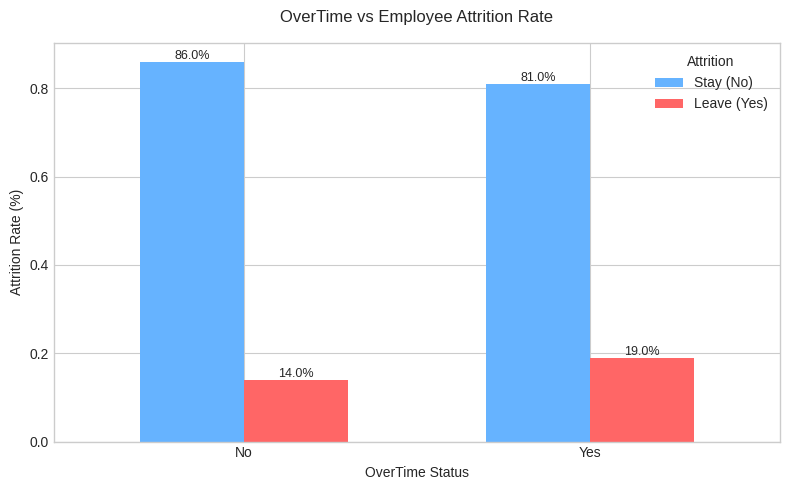

In [15]:
# Visualize Overtime vs Attrition Rate
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(8, 5))

# Plot bar chart with distinct colors (Stay = blue, Leave = red)
overtime_attrition.plot(
    kind='bar',
    ax=ax,
    color=['#66b3ff', '#ff6666'],
    width=0.6
)

# Add percentage labels on top of each bar
for container in ax.containers:
    # Multiply by 100 to convert proportion to percentage
    ax.bar_label(container, labels=[f'{v*100:.1f}%' for v in container.datavalues], label_type='edge', fontsize=9)

# Customize plot labels and title
ax.set_title('OverTime vs Employee Attrition Rate', fontsize=12, pad=15)
ax.set_xlabel('OverTime Status', fontsize=10)
ax.set_ylabel('Attrition Rate (%)', fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)  # Keep x-axis labels horizontal
ax.legend(title='Attrition', labels=['Stay (No)', 'Leave (Yes)'], loc='upper right')

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show the plot
plt.show()

4. The relationship between promotion and attrition rate

In [16]:
# Calculate Attrition Rate by Promotion Status
promotion_attrition = pd.crosstab(
    df['promotion_last_5years'],
    df['Attrition'],
    normalize='index'
)

# Print numerical results
print("\n=== Attrition Rate by Promotion Status (%) ===")
print((promotion_attrition.round(3) * 100))

# Critical: Calculate sample size
promotion_sample_size = df['promotion_last_5years'].value_counts().reset_index()
promotion_sample_size.columns = ['promotion_last_5years', 'Sample_Size']
promotion_sample_size['Percentage_of_Total'] = (promotion_sample_size['Sample_Size'] / promotion_sample_size['Sample_Size'].sum() * 100).round(2)

# Print sample size
print("\n=== Sample Size by Promotion Status ===")
print(promotion_sample_size)


=== Attrition Rate by Promotion Status (%) ===
Attrition                No    Yes
promotion_last_5years             
0                      84.0   16.0
1                       0.0  100.0

=== Sample Size by Promotion Status ===
   promotion_last_5years  Sample_Size  Percentage_of_Total
0                      0         1467                 99.8
1                      1            3                  0.2


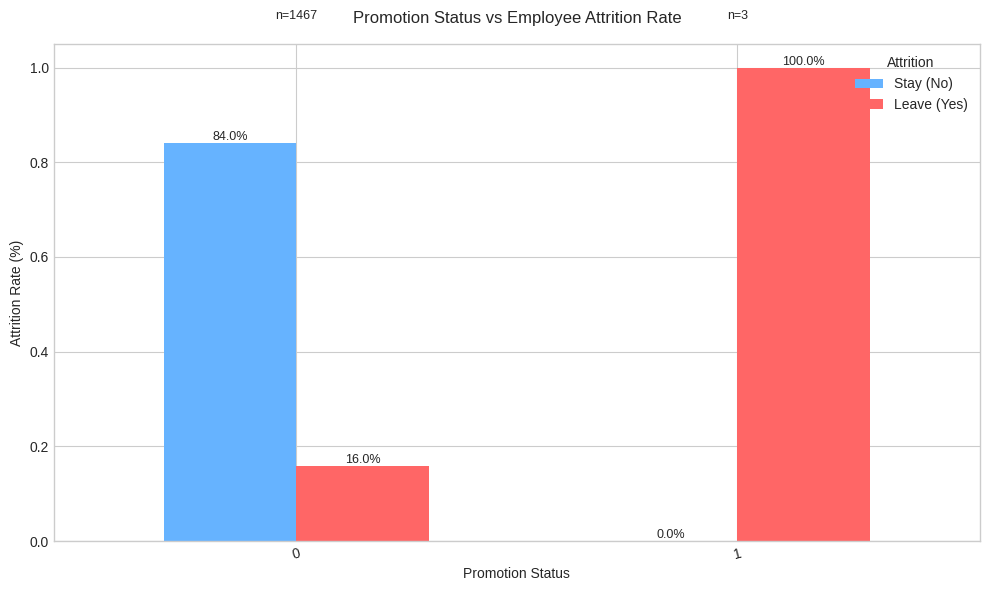

In [17]:
# Visualize Promotion vs Attrition Rate
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))

# Plot bar chart
promotion_attrition.plot(
    kind='bar',
    ax=ax,
    color=['#66b3ff', '#ff6666'],
    width=0.6
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v*100:.1f}%' for v in container.datavalues],
        label_type='edge',
        fontsize=9
    )

# Customize plot
ax.set_title('Promotion Status vs Employee Attrition Rate', fontsize=12, pad=15)
ax.set_xlabel('Promotion Status', fontsize=10)
ax.set_ylabel('Attrition Rate (%)', fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
ax.legend(title='Attrition', labels=['Stay (No)', 'Leave (Yes)'], loc='upper right')

# Add sample size annotation
sample_size_0 = promotion_sample_size[promotion_sample_size['promotion_last_5years']==0]['Sample_Size'].values[0]
sample_size_1 = promotion_sample_size[promotion_sample_size['promotion_last_5years']==1]['Sample_Size'].values[0]

ax.text(0, 1.05, f'n={sample_size_0}', ha='center', transform=ax.get_xaxis_transform(), fontsize=9)
ax.text(1, 1.05, f'n={sample_size_1}', ha='center', transform=ax.get_xaxis_transform(), fontsize=9)

plt.tight_layout()
plt.show()

Multifactor Analysis

1. Income + Overtime

In [18]:
# Set the high risk overtime threshold
print("75th percentile of average monthly working hours:", df['average_montly_hours'].quantile(0.75))

HIGH_RISK_OVERTIME_THRESHOLD = df['average_montly_hours'].quantile(0.75)

75th percentile of average monthly working hours: 239.0


In [19]:
# 2. Calculate department average salary
df['Dept_Avg_Salary'] = df.groupby('Department')['Monthly Income'].transform('mean')

print(df[['Department', 'Monthly Income', 'Dept_Avg_Salary']].head(10))
print(df[['Department', 'Monthly Income', 'Dept_Avg_Salary']].tail(5))

  Department  Monthly Income  Dept_Avg_Salary
0      Sales            5993      6959.172646
1      R & D            5130      6281.252862
2      R & D            2090      6281.252862
3      R & D            2909      6281.252862
4      R & D            3468      6281.252862
5      R & D            3068      6281.252862
6      R & D            2670      6281.252862
7      R & D            2693      6281.252862
8      R & D            9526      6281.252862
9      R & D            5237      6281.252862
     Department  Monthly Income  Dept_Avg_Salary
1465      R & D            2307      6281.252862
1466      R & D            2439      6281.252862
1467      R & D            2472      6281.252862
1468      Sales            2275      6959.172646
1469      Sales            4581      6959.172646


In [20]:
# Filter high-risk group: Below dept avg salary and >239.0 monthly hours and already flagged as "OverTime=Yes"
high_risk = df[
    (df['Monthly Income'] < df['Dept_Avg_Salary']) &
    (df['average_montly_hours'] > HIGH_RISK_OVERTIME_THRESHOLD) &
    (df['OverTime'] == 'Yes')
]

In [21]:
# Analyze attrition rate for high-risk group
if len(high_risk) > 0:
    if df['Attrition'].dtype in ['int64', 'float64']:
        high_risk_attrition_rate = (high_risk['Attrition'] == 1).mean() * 100
    else:
        high_risk_attrition_rate = (high_risk['Attrition'] == 'Yes').mean() * 100

In [22]:
# Add comparative analytics
# Overall company attrition rate
overall_attrition = (df['Attrition'] == 1).mean() * 100 if df['Attrition'].dtype in ['int64', 'float64'] else (df['Attrition'] == 'Yes').mean() * 100

# High-risk group as % of total overtime employees (reuse your OverTime distribution)
total_overtime_employees = len(df[df['OverTime'] == 'Yes'])
high_risk_overtime_ratio = (len(high_risk) / total_overtime_employees) * 100

In [23]:
if len(high_risk) > 0:
    # Print actionable insights (no redundant output)
    print("\n=== High-Risk Group Attrition Analysis ===")
    print(f"Total high-risk employees (Low Salary + Severe Overtime): {len(high_risk)}")
    print(f"High-risk group as % of all overtime employees: {high_risk_overtime_ratio:.1f}%")
    print(f"High-risk group attrition rate: {high_risk_attrition_rate:.1f}%")
    print(f"Overall company attrition rate: {overall_attrition:.1f}%")
    print(f"Risk multiplier (High-risk vs Overall): {high_risk_attrition_rate/overall_attrition:.2f}x")

    # Optional: Breakdown by OverTime (reuse your column for deeper insights)
    high_risk_overtime_attr = high_risk.groupby('OverTime')['Attrition'].apply(
          lambda x: (x == 'Yes').mean() * 100 if df['Attrition'].dtype == 'object' else (x == 1).mean() * 100
        )
    print("\n=== High-Risk Group Attrition by Overtime Status ===")
    print(high_risk_overtime_attr.round(1))
else:
    print("\n⚠️ No employees meet high-risk criteria (Below dept avg salary + >240 monthly hours)")


=== High-Risk Group Attrition Analysis ===
Total high-risk employees (Low Salary + Severe Overtime): 259
High-risk group as % of all overtime employees: 41.4%
High-risk group attrition rate: 29.7%
Overall company attrition rate: 16.1%
Risk multiplier (High-risk vs Overall): 1.84x

=== High-Risk Group Attrition by Overtime Status ===
OverTime
Yes    29.7
Name: Attrition, dtype: float64


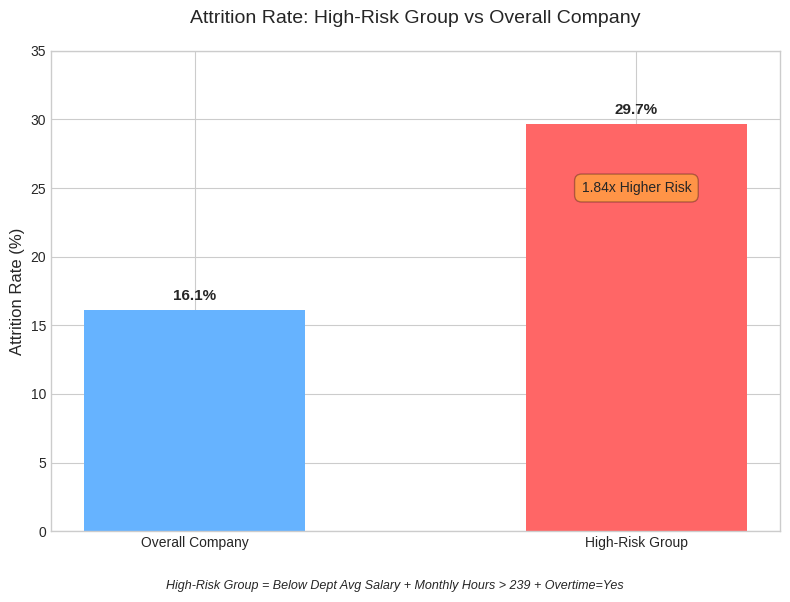

In [24]:
# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.size'] = 10

# Prepare data
categories = ['Overall Company', 'High-Risk Group']
attrition_rates = [16.1, 29.7]  # Overall:16.1%, High-risk:29.7%
colors = ['#66b3ff', '#ff6666']  # Blue=Overall, Red=High-risk

# Create bar chart
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(categories, attrition_rates, color=colors, width=0.5)

# Add percentage labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2.,
        height + 0.5,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# Add risk multiplier annotation
ax.text(
    1,  # X position (high-risk group bar)
    25, # Y position
    f'1.84x Higher Risk',
    ha='center',
    va='center',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.3),
    fontsize=10
)

# Set plot labels and title
ax.set_title('Attrition Rate: High-Risk Group vs Overall Company', fontsize=14, pad=20)
ax.set_ylabel('Attrition Rate (%)', fontsize=12)
ax.set_ylim(0, 35)  # Set y-axis limit for better visual contrast

# Add subtitle for high-risk definition (context for viewers)
plt.figtext(
    0.5, 0.01,
    'High-Risk Group = Below Dept Avg Salary + Monthly Hours > 239 + Overtime=Yes',
    ha='center',
    fontsize=9,
    style='italic'
)

# Show  the plot
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

2. Project Count + Monthly Hours

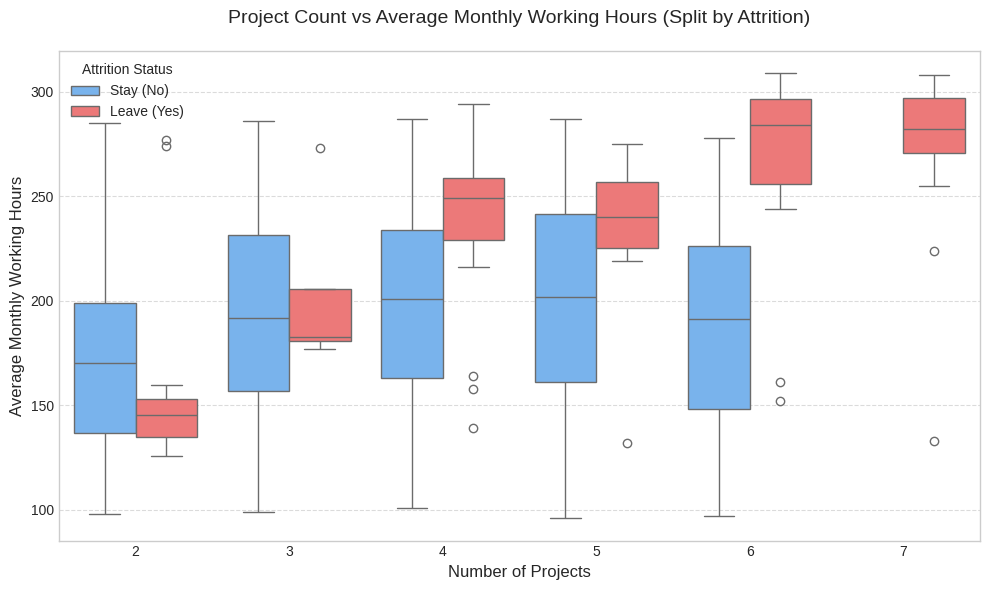

In [25]:
# Set professional plot style for consistency across visualizations
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))

# Generate boxplot to show relationship between project count, monthly hours and attrition
sns.boxplot(
    x='number_project',
    y='average_montly_hours',
    hue='Attrition',
    data=df,
    ax=ax,
    hue_order=['No', 'Yes'],
    palette={'No': '#66b3ff', 'Yes': '#ff6666'}
)

handles, labels = ax.get_legend_handles_labels()

# Recreate legend with correct labels and title
ax.legend(
    handles=handles,
    labels=['Stay (No)', 'Leave (Yes)'],
    title='Attrition Status',
    loc='upper left'
)

# Customize plot titles and axis labels
ax.set_title(
    'Project Count vs Average Monthly Working Hours (Split by Attrition)',
    fontsize=14,
    pad=20
)
ax.set_xlabel('Number of Projects', fontsize=12)
ax.set_ylabel('Average Monthly Working Hours', fontsize=12)

# Add subtle horizontal grid lines for better readability of y-axis values
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Display the result
plt.tight_layout()
plt.show()

Correlation Heatmap for Attrition

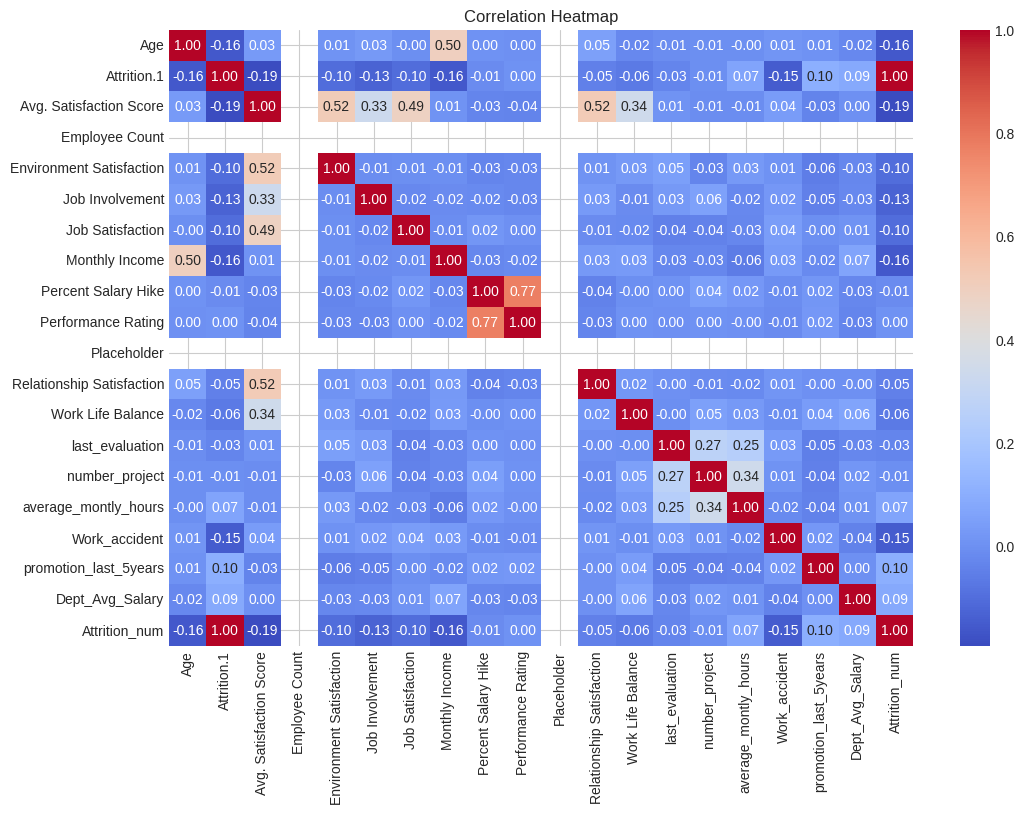

In [26]:
# Convert "attrition" to numerical values for correlation calculation
df['Attrition_num'] = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Visualizing the "Overwork Trap": Combined Impact of Monthly Hours and Project Counts

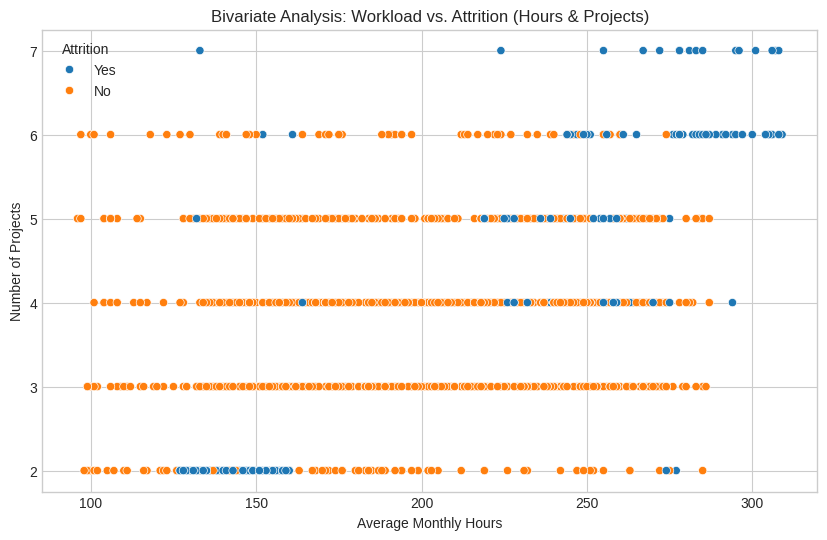

In [27]:
# 1. Set the figure size
plt.figure(figsize=(10, 6))

# 2. Plot scatter plot (X-axis: Hours, Y-axis: Projects, Color: Attrition status)
sns.scatterplot(data=df, x='average_montly_hours', y='number_project', hue='Attrition')

# 3. Set the plot title and labels
plt.title('Bivariate Analysis: Workload vs. Attrition (Hours & Projects)')
plt.xlabel('Average Monthly Hours')
plt.ylabel('Number of Projects')

# 4. Display the plot
plt.show()

# Stage 3: Feature Engineering

### 1.Feature Derivation  (特征衍生)


In [28]:
# 定义“过劳”：月均工时 > 240 且 项目数 >= 6
# Define 'is_overworked': Monthly hours > 240 AND Projects >= 6
df['is_overworked'] = ((df['average_montly_hours'] > 240) & (df['number_project'] >= 6)).astype(int)
print(f"Number of overworked employees identified: {df['is_overworked'].sum()}")

Number of overworked employees identified: 67


### 2. Target Encoding (目标变量编码)

In [29]:
# Convert target variable 'Attrition' to numeric: 1 (Yes) and 0 (No)
# 将目标变量 Attrition 转换为数字：1 (Yes) 和 0 (No)
df['target'] = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

### 3. Feature Selection - Basic / 基础特征筛选

In [30]:
# ==========================================================

# Define the list of columns to be removed
# 定义需要剔除的列清单
cols_to_drop = [
    'emp_id',            # Pure ID, no predictive value / 纯ID，无预测价值
    'Attrition',         # Original text label, replaced by 'target' / 原始文本标签，已被 target 取代
    'attrition_num',     # Intermediate variable from previous steps / 之前的中间变量，避免重复
    'Attrition.1',       # Duplicate column from raw data / 原始表自带的重复列
    'Age group',         # Redundant since continuous 'Age' exists / 已有连续型变量 Age，不需要分组变量
    'Employee Count',    # Constant value (1), no info / 常量值 (1)，无预测价值
    'Placeholder',       # Constant value (0), no info / 常量值 (0)，无预测价值
    'OverTime',          # Replaced by our precise 'is_overworked' / 已被更精准的 is_overworked 取代
    'Work Location',     # Low variance across samples / 地点差异不大，选择剔除以简化模型
    'Dept_Avg_Salary',   # Intermediate calculation column / 之前的中间计算列


    # These columns directly leak the answer, causing a fake 1.0 correlation
    # 这些列直接泄露了答案，会导致虚假的 1.0 相关性，必须删除
    'Attrition Label_Current Employees',
    'Attrition Label_Attrited Employees'
]

# Execute the drop operation
# 执行剔除操作
df_model = df.drop(columns=cols_to_drop, errors='ignore')

print(f"Cleanup complete! Remaining columns: {df_model.shape[1]}")
# 清理完成！剩余列数：{df_model.shape[1]}

Cleanup complete! Remaining columns: 24


### 4. Categorical Encoding - One-Hot / 分类变量编码（独热编码）

In [31]:
# Convert categorical text (Dept, Role, Gender) into numeric (0/1)
# 将分类文本（部门、职位、性别等）转换为数字 (0/1)，即独热编码
# drop_first=True helps to avoid multicollinearity
# drop_first=True 有助于避免多重共线性（例如：男=1，则女默认为0）
df_final = pd.get_dummies(df_model, drop_first=True)

print(f"One-Hot Encoding complete! Final feature count: {df_final.shape[1]}")
# 独热编码完成！最终特征总数：{df_final.shape[1]}

One-Hot Encoding complete! Final feature count: 39


### 5. Feature Correlation Check / 特征相关性检查

In [32]:
# ==========================================================

# Check which features have the strongest correlation with 'target'
# 检查哪些特征与目标变量 'target' 的相关性最强
correlations = df_final.corr()['target'].sort_values(ascending=False)

print("\n--- Top 5 Positively Correlated Features / 前5个正相关特征 ---")
print(correlations.head(6)) # Including target itself / 包含 target 自身

print("\n--- Top 5 Negatively Correlated Features / 前5个负相关特征 ---")
print(correlations.tail(5))


--- Top 5 Positively Correlated Features / 前5个正相关特征 ---
target                            1.000000
Attrition_num                     1.000000
is_overworked                     0.418619
Job Role_Sales Representative     0.157234
promotion_last_5years             0.103146
Job Role_Laboratory Technician    0.098290
Name: target, dtype: float64

--- Top 5 Negatively Correlated Features / 前5个负相关特征 ---
Work_accident                       -0.150969
Age                                 -0.159205
Monthly Income                      -0.159840
Avg. Satisfaction Score             -0.193395
Attrition Label_Current Employees   -1.000000
Name: target, dtype: float64


## Stage 4: Model Building

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [34]:
# --- Step 1: Feature Cleaning (Preventing Data Leakage) ---
# Remove target variables, their variants, non-predictive IDs, and constant columns
drop_list = [
    'Attrition',
    'Attrition Label',
    'attrition_num',
    'Attrition_num',
    'Attrition.1',
    'target',
    'emp_id',
    'Employee Count',
    'Placeholder',
    'Dept_Avg_Salary',
    'OverTime'
]

# Extract target variable (y) + feature matrix (X)
# Target variable: Convert Attrition to numeric (Yes=1 for attrition, No=0 for retention)
y = df['Attrition'].map({'Yes': 1, 'No': 0})
# Feature matrix: Drop redundant/target columns, keep raw features only
X = df.drop(columns=drop_list, errors='ignore')

# One-hot encode categorical features (only once to avoid duplicate encoding)
X = pd.get_dummies(X, drop_first=True)
# Reset index to avoid data misalignment in train_test_split
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

print(f"Feature engineering completed. Final feature dimension: {X.shape}")
print(f"Final feature list:\n{X.columns.tolist()}")

Feature engineering completed. Final feature dimension: (1470, 45)
Final feature list:
['Age', 'Avg. Satisfaction Score', 'Environment Satisfaction', 'Job Involvement', 'Job Satisfaction', 'Monthly Income', 'Percent Salary Hike', 'Performance Rating', 'Relationship Satisfaction', 'Work Life Balance', 'last_evaluation', 'number_project', 'average_montly_hours', 'Work_accident', 'promotion_last_5years', 'is_overworked', 'Gender_Male', "Education_Bachelor's Degree", 'Education_Doctoral Degree', 'Education_High School', "Education_Master's Degree", 'Education Field_Life Sciences', 'Education Field_Marketing', 'Education Field_Medical', 'Education Field_Other', 'Education Field_Technical Degree', 'Job Role_Human Resources', 'Job Role_Laboratory Technician', 'Job Role_Manager', 'Job Role_Manufacturing Director', 'Job Role_Research Director', 'Job Role_Research Scientist', 'Job Role_Sales Executive', 'Job Role_Sales Representative', 'Department_R & D', 'Department_Sales', 'Age group_35-44', '

In [35]:
# Step 2: Train-test split + Standardization
# Split data 7:3 (train:test) with stratification to preserve attrition rate distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [36]:
# Step 3: Model Training
# 1. Logistic Regression
lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=500)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

# 2. Random Forest
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [37]:
# Step 4: Model Evaluation Reports
print("\n" + "="*20, "Logistic Regression Evaluation", "="*20)
print(classification_report(y_test, lr_pred, target_names=['Stayed (0)', 'Left (1)']))
print("\n" + "="*20, "Random Forest Evaluation", "="*20)
print(classification_report(y_test, rf_pred, target_names=['Stayed (0)', 'Left (1)']))


==================== Logistic Regression Evaluation ====================
              precision    recall  f1-score   support

  Stayed (0)       0.93      0.82      0.87       370
    Left (1)       0.42      0.69      0.52        71

    accuracy                           0.80       441
   macro avg       0.68      0.75      0.70       441
weighted avg       0.85      0.80      0.81       441


==================== Random Forest Evaluation ====================
              precision    recall  f1-score   support

  Stayed (0)       0.93      1.00      0.96       370
    Left (1)       0.98      0.59      0.74        71

    accuracy                           0.93       441
   macro avg       0.95      0.79      0.85       441
weighted avg       0.94      0.93      0.92       441



/tmp/ipykernel_551/619369564.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


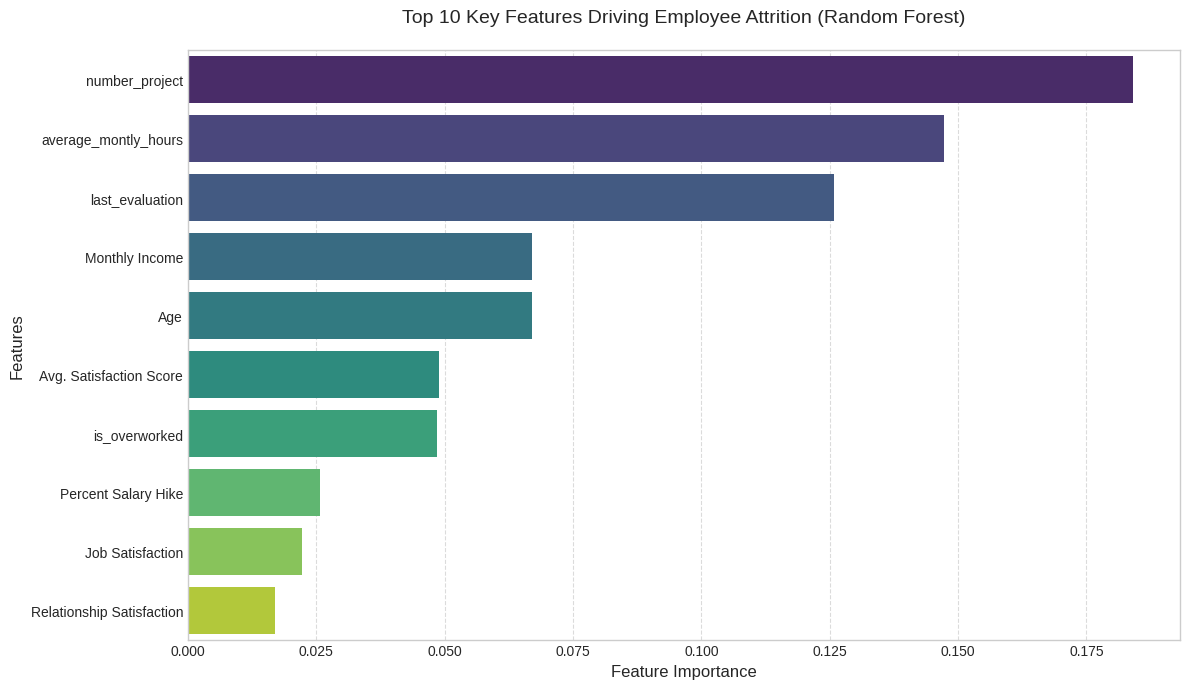

In [38]:
# Step 5: Feature Importance Visualization
# Extract Random Forest feature importance and map to feature names
importances = rf_model.feature_importances_
feature_imp_df = pd.DataFrame({
    'Feature': X.columns,  # Directly use X's column names for perfect matching
    'Importance': importances
})

# Sort by importance (descending) and select TOP 10 key features
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False).head(10)

# Plot TOP 10 features driving attrition (optimized visualization)
plt.figure(figsize=(12, 7))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_imp_df,
    palette='viridis'  # Avoid FutureWarning from redundant hue parameter
)

# Customize plot
plt.title('Top 10 Key Features Driving Employee Attrition (Random Forest)', fontsize=14, pad=20)
plt.xlabel('Feature Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()  # Prevent label truncation
plt.show()